<a href="https://colab.research.google.com/github/selvamaran/a26cnW2D2_timeseries/blob/main/real_data_EEG_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://openneuro.org/datasets/ds004148/versions/1.0.1

In [1]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 49.8 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [8]:
import mne
import os
import matplotlib.pyplot as plt

In [6]:
# folder_path = '/content/drive/MyDrive/EEG'
folder_path = '/content'

In [ ]:
import os

download_url = "https://github.com/selvamaran/a26cnW2D2_timeseries/raw/main/sub-01_ses-session1_task-eyesclosed_eeg_ds004148.zip"
zip_file_name = "sub-01_ses-session1_task-eyesclosed_eeg_ds004148.zip"
folder_path = '/content'
output_path = os.path.join(folder_path, zip_file_name)

print(f"Downloading {zip_file_name} from {download_url} to {output_path}")
!wget -O {output_path} {download_url}
print("Download complete.")


In [ ]:
print(f"Extracting {zip_file_name} to {folder_path}")
!unzip -o {output_path} -d {folder_path}
print("Extraction complete.")

Archive:  sub-01_ses-session1_task-eyesclosed_eeg_ds004148.zip
  inflating: sub-01_ses-session1_task-eyesclosed_eeg_ds004148.eeg  


In [9]:
import os

eeg_file_path = folder_path + '/sub-01_ses-session1_task-eyesclosed_eeg_ds004148.eeg'
vhdr_file_path = eeg_file_path.replace('.eeg', '.vhdr')

if os.path.exists(vhdr_file_path):
    print(f"Loading BrainVision data from: {vhdr_file_path}")

    # --- Start of fix for .vmrk and .eeg filenames in .vhdr file ---
    base_name = os.path.basename(vhdr_file_path).replace('.vhdr', '')
    correct_vmrk_filename_in_vhdr = base_name + '.vmrk'
    correct_eeg_filename_in_vhdr = base_name + '.eeg'

    # Read the content of the .vhdr file
    with open(vhdr_file_path, 'r') as f:
        vhdr_content = f.readlines()

    modified_vhdr_content = []
    vmrk_line_found = False
    datafile_line_found = False

    for line in vhdr_content:
        if line.strip().startswith('MarkerFile='):
            modified_line = f"MarkerFile={correct_vmrk_filename_in_vhdr}\n"
            modified_vhdr_content.append(modified_line)
            vmrk_line_found = True
            print(f"Modified MarkerFile entry in .vhdr to: {modified_line.strip()}")
        elif line.strip().startswith('DataFile='):
            modified_line = f"DataFile={correct_eeg_filename_in_vhdr}\n"
            modified_vhdr_content.append(modified_line)
            datafile_line_found = True
            print(f"Modified DataFile entry in .vhdr to: {modified_line.strip()}")
        else:
            modified_vhdr_content.append(line)

    if not vmrk_line_found:
        print("Warning: 'MarkerFile=' entry not found in .vhdr file. This might cause issues.")
    if not datafile_line_found:
        print("Warning: 'DataFile=' entry not found in .vhdr file. This might cause issues.")

    # Write the modified content back to the .vhdr file
    with open(vhdr_file_path, 'w') as f:
        f.writelines(modified_vhdr_content)
    # --- End of fix ---

    raw = mne.io.read_raw_brainvision(vhdr_file_path, preload=True)
    print("\n--- Metadata for the specified BrainVision file ---")
    print(raw.info)
else:
    print(f"Error: Corresponding .vhdr file not found at {vhdr_file_path}")
    print("BrainVision files (.eeg) require a .vhdr header file for MNE to load them.")

Loading BrainVision data from: /content/sub-01_ses-session1_task-eyesclosed_eeg_ds004148.vhdr
Modified DataFile entry in .vhdr to: DataFile=sub-01_ses-session1_task-eyesclosed_eeg_ds004148.eeg
Modified MarkerFile entry in .vhdr to: MarkerFile=sub-01_ses-session1_task-eyesclosed_eeg_ds004148.vmrk
Extracting parameters from /content/sub-01_ses-session1_task-eyesclosed_eeg_ds004148.vhdr...
Setting channel info structure...
Reading 0 ... 149999  =      0.000 ...   299.998 secs...

--- Metadata for the specified BrainVision file ---
<Info | 7 non-empty values
 bads: []
 ch_names: Fp1, AF3, AF7, Fz, F1, F3, F5, F7, FC1, FC3, FC5, FT7, Cz, C1, ...
 chs: 61 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 61
 projs: []
 sfreq: 500.0 Hz
>


In [11]:
# Get and print metadata details
raw.info

<Info | 7 non-empty values
 bads: []
 ch_names: Fp1, AF3, AF7, Fz, F1, F3, F5, F7, FC1, FC3, FC5, FT7, Cz, C1, ...
 chs: 61 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 61
 projs: []
 sfreq: 500.0 Hz
>

In [12]:
# raw.plot?

Using matplotlib as 2D backend.


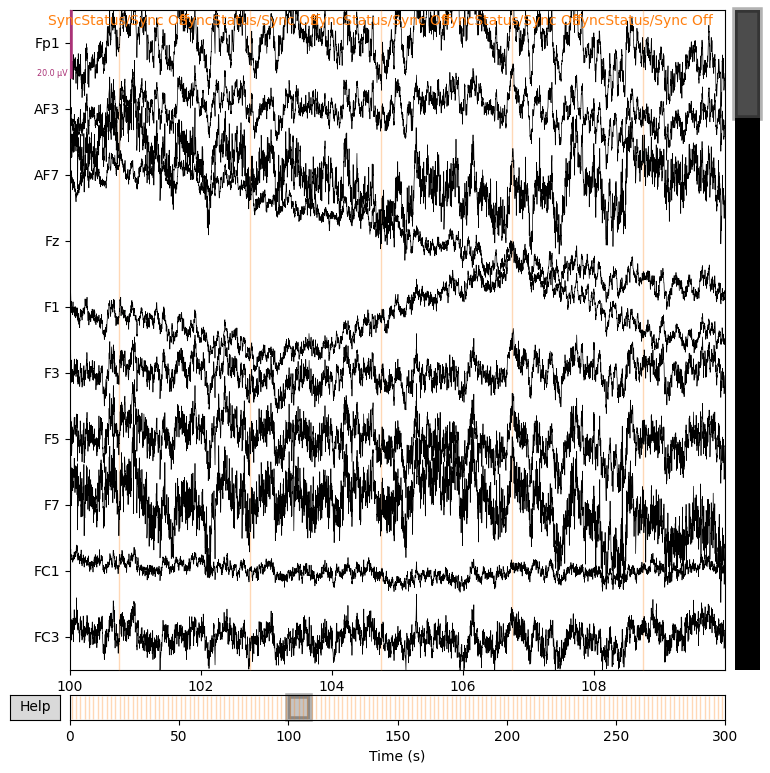

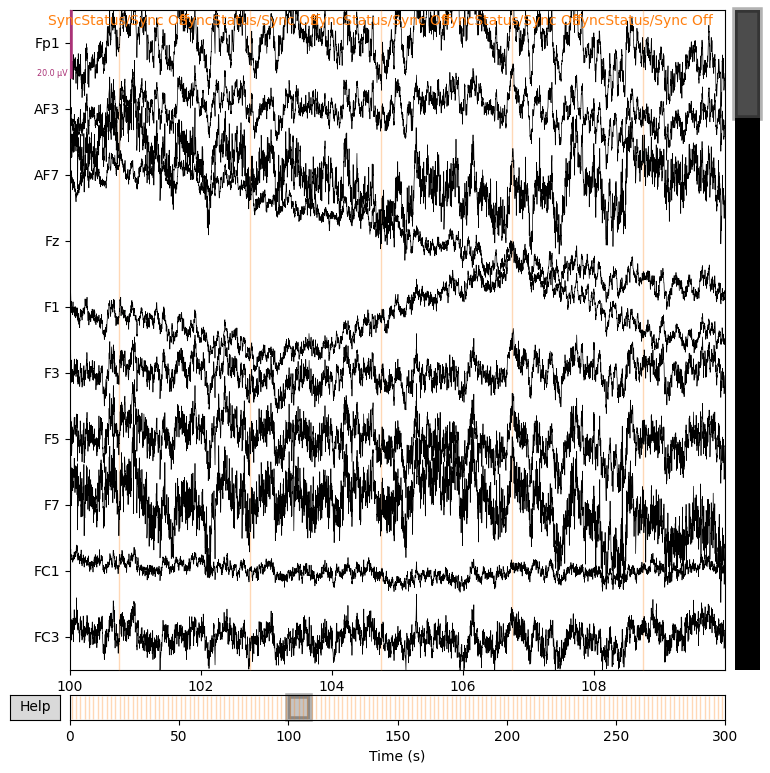

In [13]:
# Visualize the EEG signal
# The 'block=True' argument keeps the plot open until closed manually.
# Adjust 'n_channels' to plot a specific number of channels, or remove it to plot all.
# You can also use 'scalings' to adjust the amplitude of the signals for better visualization.
raw.plot(n_channels=10, start=100.0, scalings={'eeg': 100e-7}, block=False)

In [14]:
print(f"Channel names: {raw.info['ch_names']}")
print(f"Sampling frequency: {raw.info['sfreq']} Hz")

Channel names: ['Fp1', 'AF3', 'AF7', 'Fz', 'F1', 'F3', 'F5', 'F7', 'FC1', 'FC3', 'FC5', 'FT7', 'Cz', 'C1', 'C3', 'C5', 'T7', 'CP1', 'CP3', 'CP5', 'TP7', 'TP9', 'Pz', 'P1', 'P3', 'P5', 'P7', 'PO3', 'PO7', 'Oz', 'O1', 'Fpz', 'Fp2', 'AF4', 'AF8', 'F2', 'F4', 'F6', 'F8', 'FC2', 'FC4', 'FC6', 'FT8', 'C2', 'C4', 'C6', 'T8', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'TP10', 'P2', 'P4', 'P6', 'P8', 'POz', 'PO4', 'PO8', 'O2']
Sampling frequency: 500.0 Hz


Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_22792/3198479211.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd().plot();


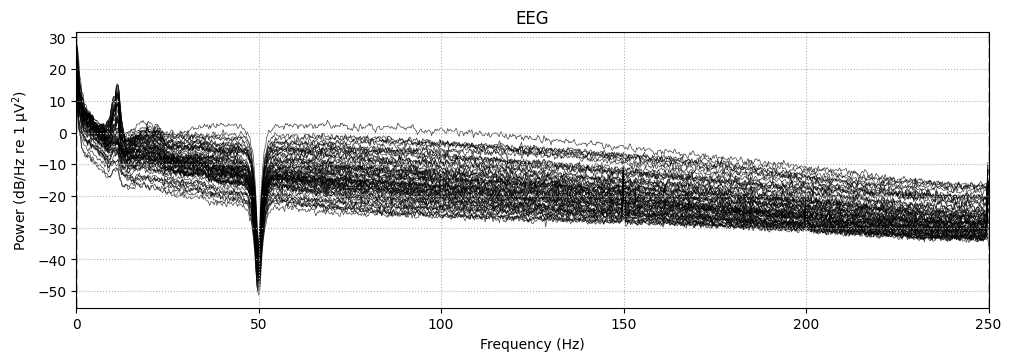

In [15]:
raw.compute_psd().plot();

Plotting power spectral density (dB=True).


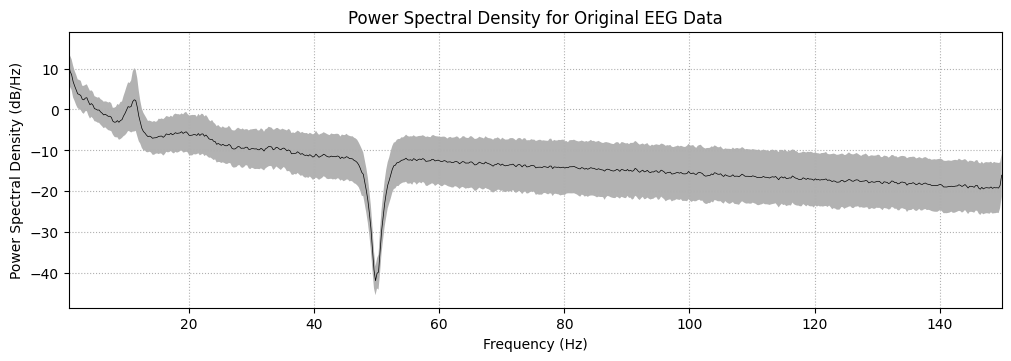

In [16]:
# Calculate the Power Spectral Density (PSD) for the original data
# 'fmin' and 'fmax' define the frequency range to consider.
# 'picks' can be used to select specific channels (e.g., 'eeg' for all EEG channels).
spectrum_original = raw.compute_psd(method='welch', fmin=0.5,fmax=150,  picks='eeg', verbose=False)

# Plot the PSD using the Spectrum object's plot method
fig_original = spectrum_original.plot(average=True, spatial_colors=True, exclude=['EEG A2-A1', 'EEG 23A-23R', 'EEG 24A-24R'], show=False)
fig_original.axes[0].set_xlabel('Frequency (Hz)')
fig_original.axes[0].set_ylabel('Power Spectral Density (dB/Hz)')
fig_original.axes[0].set_title('Power Spectral Density for Original EEG Data')
fig_original.show()

### Apply Bandpass Filter

Now, let's apply a bandpass filter to the `raw_brainvision` data to remove frequencies outside the range of 0.5 Hz to 40 Hz. This is a common preprocessing step in EEG analysis to focus on brain-related activity and remove noise.

In [17]:
# Apply a bandpass filter to the raw_brainvision data
raw_filtered = raw.copy().filter(l_freq=0.5, h_freq=40, picks='eeg', verbose=False)

print("Bandpass filter (0.5-40 Hz) applied successfully.")

Bandpass filter (0.5-40 Hz) applied successfully.


Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_22792/2957585126.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_filtered.compute_psd().plot();


(0.0, 80.0)

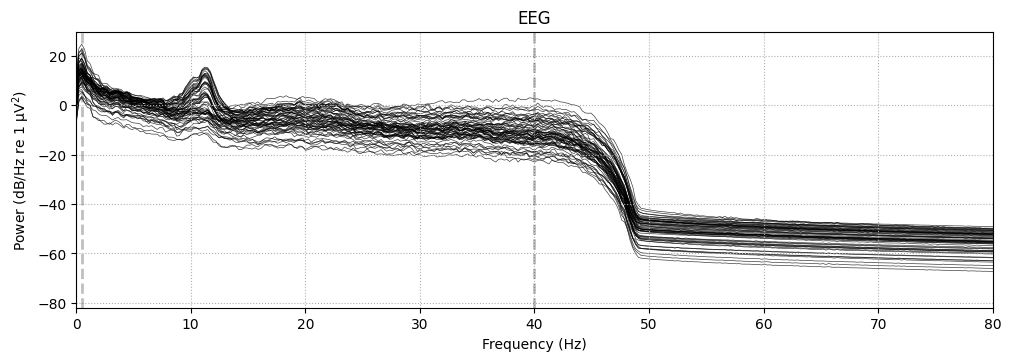

In [18]:
raw_filtered.compute_psd().plot();
plt.xlim([0,80])

Plotting power spectral density (dB=True).


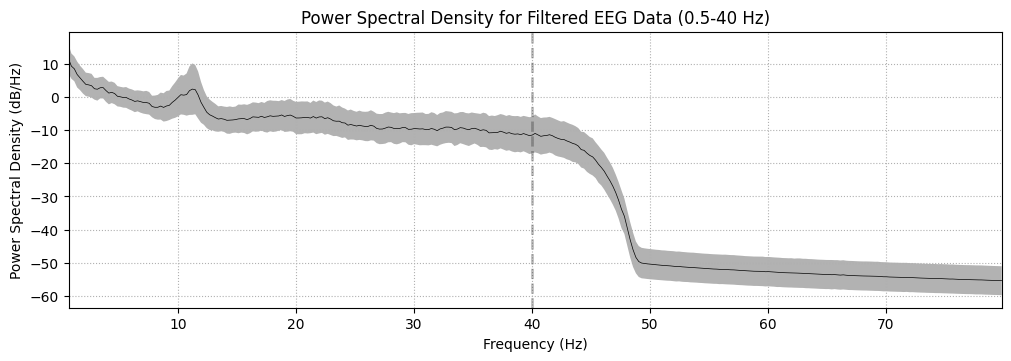

In [19]:
# Calculate the Power Spectral Density (PSD) for the filtered data
spectrum_filtered = raw_filtered.compute_psd(method='welch', fmin=0.5, fmax=80, picks='eeg', verbose=False)

# Plot the PSD using the Spectrum object's plot method
fig_filtered = spectrum_filtered.plot(average=True, spatial_colors=True, exclude='bads', show=False)
fig_filtered.axes[0].set_xlabel('Frequency (Hz)')
fig_filtered.axes[0].set_ylabel('Power Spectral Density (dB/Hz)')
fig_filtered.axes[0].set_title('Power Spectral Density for Filtered EEG Data (0.5-40 Hz)')
fig_filtered.show()

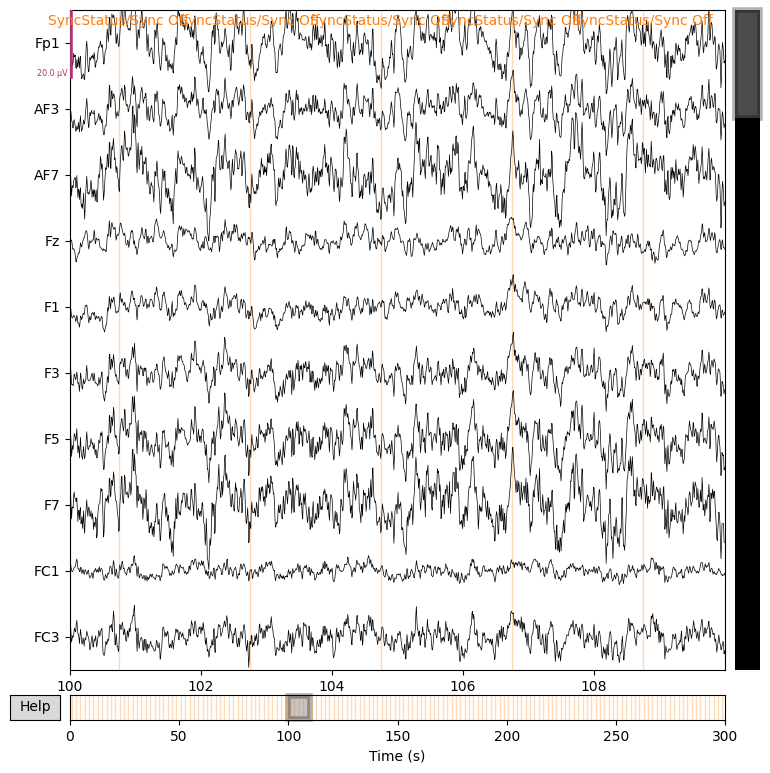

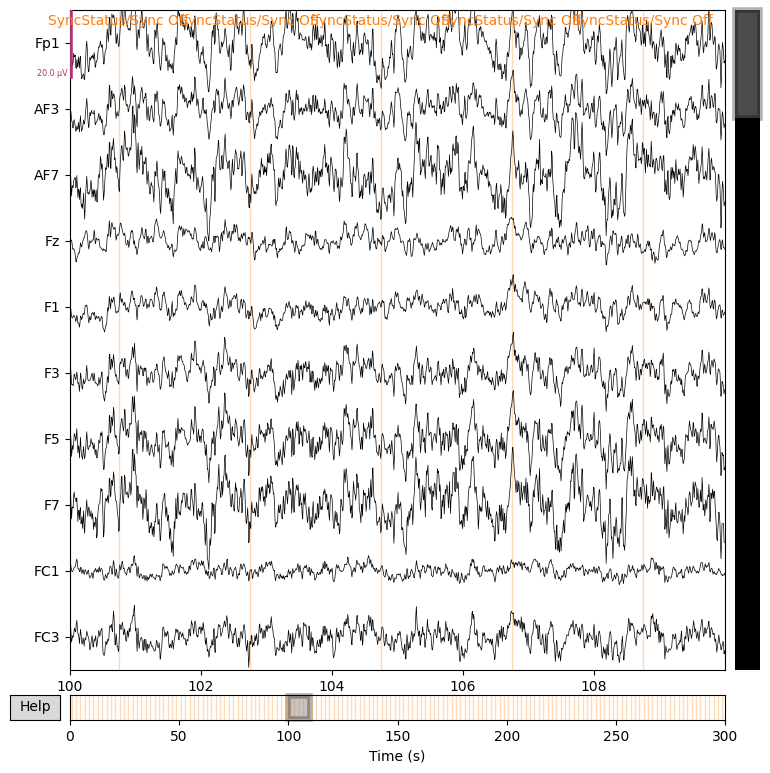

In [20]:
raw_filtered.plot(n_channels=10, start=100.0, scalings={'eeg': 100e-7}, block=False)

Plotting power spectral density (dB=True).


/tmp/ipykernel_22792/1482948366.py:16: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig_original = spectrum_original.plot(average=False, spatial_colors=True, exclude=['EEG A2-A1', 'EEG 23A-23R', 'EEG 24A-24R'], show=False)


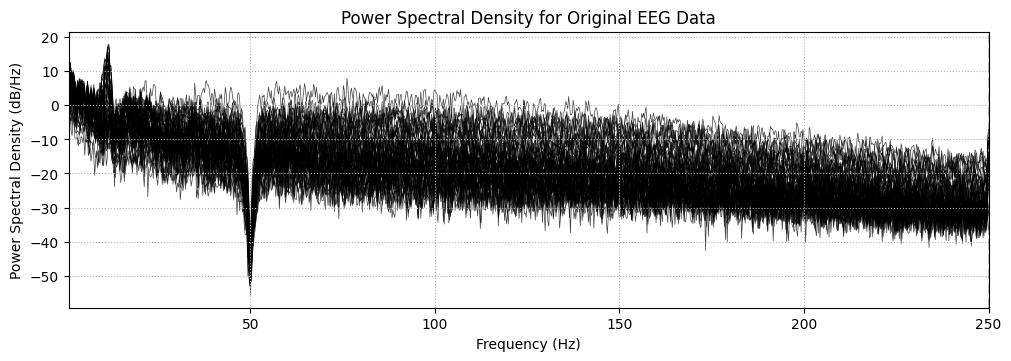

In [21]:
# Extract a specific time interval (e.g., from 0 to 10 seconds)
# This creates a *new* Raw object with the cropped data.
# 'tmin' is the start time in seconds, 'tmax' is the end time in seconds.
raw_cropped = raw.copy().crop(tmin=100, tmax=120)

# print("\n--- Info for Cropped Data (0-10 seconds) ---")
# print(raw_cropped.info)


# Calculate the Power Spectral Density (PSD) for the original data
# 'fmin' and 'fmax' define the frequency range to consider.
# 'picks' can be used to select specific channels (e.g., 'eeg' for all EEG channels).
spectrum_original = raw_cropped.compute_psd(method='welch', fmin=0.5,  picks='eeg', verbose=False)

# Plot the PSD using the Spectrum object's plot method
fig_original = spectrum_original.plot(average=False, spatial_colors=True, exclude=['EEG A2-A1', 'EEG 23A-23R', 'EEG 24A-24R'], show=False)
fig_original.axes[0].set_xlabel('Frequency (Hz)')
fig_original.axes[0].set_ylabel('Power Spectral Density (dB/Hz)')
fig_original.axes[0].set_title('Power Spectral Density for Original EEG Data')
fig_original.show()

Plotting power spectral density (dB=True).


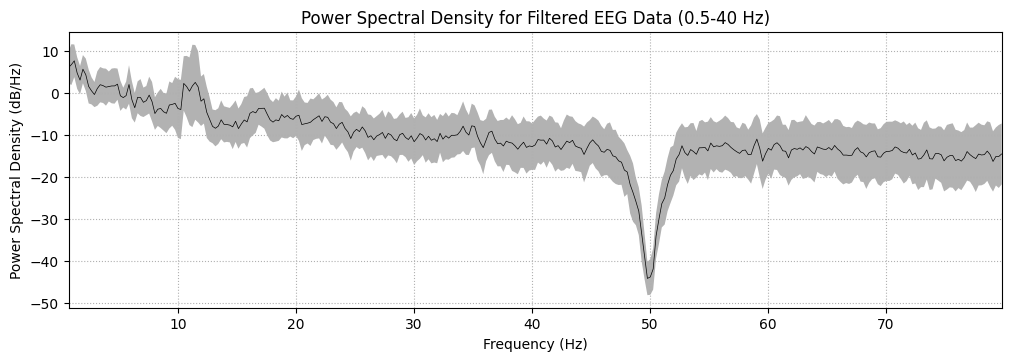

In [22]:
# Calculate the Power Spectral Density (PSD) for the filtered data
spectrum_cropped = raw_cropped.compute_psd(method='welch', fmin=0.5, fmax=80, picks='eeg', verbose=False)

# Plot the PSD using the Spectrum object's plot method
fig_filtered = spectrum_cropped.plot(average=True, spatial_colors=True, exclude='bads', show=False)
fig_filtered.axes[0].set_xlabel('Frequency (Hz)')
fig_filtered.axes[0].set_ylabel('Power Spectral Density (dB/Hz)')
fig_filtered.axes[0].set_title('Power Spectral Density for Filtered EEG Data (0.5-40 Hz)')
fig_filtered.show()